=== Step 1: system parameters ===
tau = 1.000e-03 s, omega = 6.283e+02 rad/s, dt = 1.0e-05 s
dt/tau = 0.0100, dt*omega = 0.0063  (both small -> Strang splitting should be very accurate)

=== Step 2: K / S decomposition ===
Eigenvalues of dissipative part S: [-1207.10678119     0.             0.           207.10678119]
Per-step contraction factors r_i : [0.985957 0.997931 0.997931 1.      ]
Classical rescale factor per step g = 1.0020732140

=== Step 3: building one-step quantum circuit ===


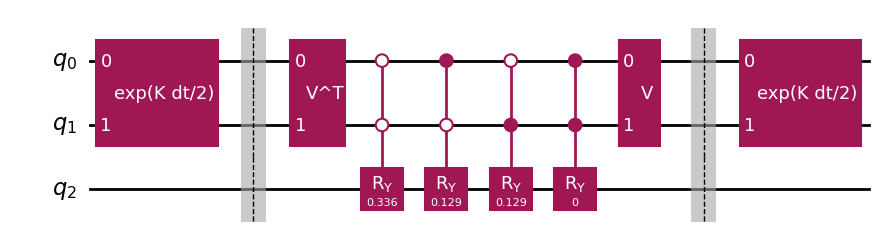


=== Step 4: verifying circuit against exact matrix math ===
||circuit (ancilla=0 block) - exact (K,S)-step||_F = 2.725e-16
Verification SUCCESS: the circuit exactly implements the dilated RC step.

=== Step 5: running the dilated Trotter evolution ===
Average per-step state fidelity              : 0.999958
Post-selection success probability at t=0.015s : 0.0030


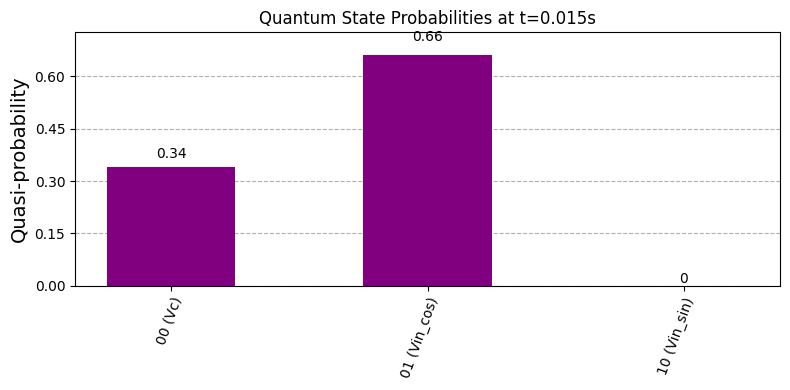


=== Step 7: frequency sweep (Bode plot) ===

=== Step 8: generating final output graphs ===


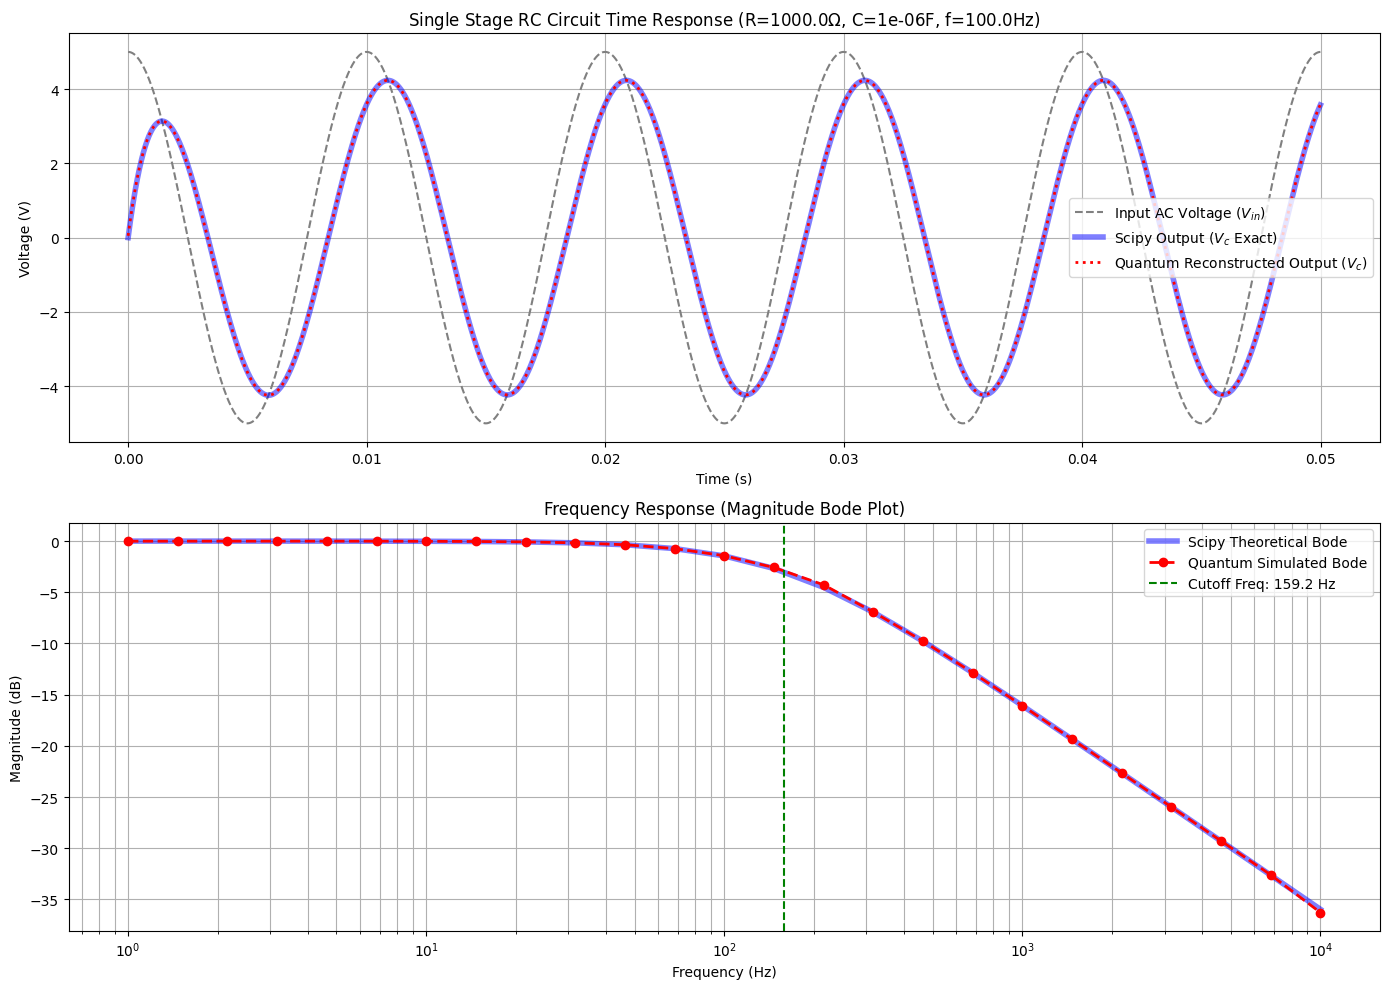

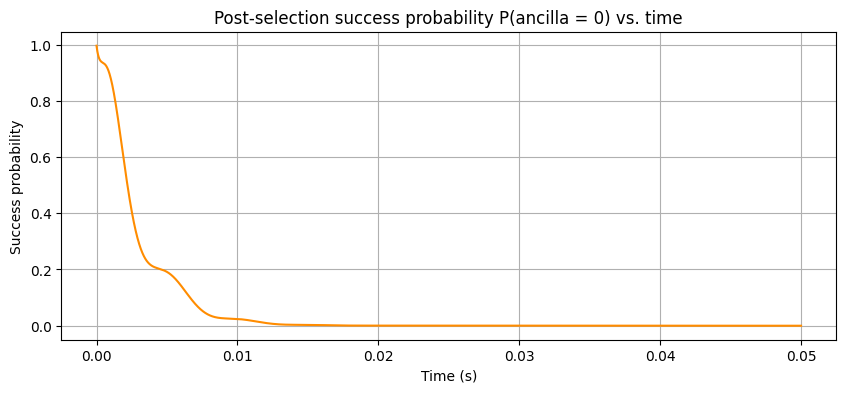


=== Final summary ===
Average per-step state fidelity   : 0.999958
Relative L2 error of Vc(t)        : 6.565967e-03
Overall trajectory fidelity proxy : 0.986911


In [ ]:
# Include necessarry libraries
%matplotlib inline
import numpy as np
import scipy.linalg
from scipy.integrate import odeint
import scipy.signal as signal
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator
from qiskit.circuit.library import UnitaryGate, RYGate
from qiskit.visualization import plot_histogram
from IPython.display import display

######################
# 1. System parameters
######################

R = 1000.0       # Resistance (ohms)
C = 1e-6         # Capacitance (farads)
tau = R * C      # Time constant (seconds)
f = 100.0        # AC Input Frequency (in Hz)
omega = 2 * np.pi * f
V0 = 5.0         # AC Voltage Amplitude (volts)

t_max = 0.05     # 50 ms simulation
dt = 0.00001     # 10 microsecond Trotter step
times = np.arange(0, t_max, dt)
n_steps = len(times)
target_time = 0.015 # Timestamp for the histogram (15ms)
target_step = int(target_time / dt)

A_matrix = np.array([
    [-1/tau,  1/tau,      0, 0],
    [     0,      0, -omega, 0],
    [     0,  omega,      0, 0],
    [     0,      0,      0, 0]
])

print("=== Step 1: system parameters ===")
print(f"tau = {tau:.3e} s, omega = {omega:.3e} rad/s, dt = {dt:.1e} s")
print(f"dt/tau = {dt/tau:.4f}, dt*omega = {dt*omega:.4f}  (both small -> Strang splitting should be very accurate)")

#####################################################################
# 2. Split generator: K (unitary rotation) + S (non-unitary dilation)
#####################################################################

K = (A_matrix - A_matrix.T) / 2 # anit-symmetric part of A, generates unitary rotation
S = (A_matrix + A_matrix.T) / 2 # symmetric part of A, generates non-unitary contraction/dilation

lam, V_eig = np.linalg.eigh(S)             # S = V_eig @ diag(lam) @ V_eig.T
lam_max = np.max(lam)
r = np.exp((lam - lam_max) * dt)           # per-eigenmode contraction factors, all <= 1
g_step = np.exp(lam_max * dt)              # classical rescale factor per step (known constant, >= 1)

print("\n=== Step 2: K / S decomposition ===")
print("Eigenvalues of dissipative part S:", lam)
print("Per-step contraction factors r_i :", np.round(r, 6))
print(f"Classical rescale factor per step g = {g_step:.10f}")

R_half = scipy.linalg.expm(K * dt / 2)     # exact orthogonal (unitary) half-step from K
thetas = 2 * np.arccos(np.clip(r, -1.0, 1.0))

#################################################
# 3. One Strang step as an actual quantum circuit
#################################################

print("\n=== Step 3: building one-step quantum circuit ===")

def build_one_step_circuit():
    qc = QuantumCircuit(3, name="strang_step")   # qubits 0,1 = main register ; qubit 2 = ancilla
    main_qubits = [0, 1]
    ancilla = 2

    qc.append(UnitaryGate(R_half, label="exp(K dt/2)"), main_qubits)
    qc.barrier()

    # Rotate into the eigenbasis of S
    qc.append(UnitaryGate(V_eig.T, label="V^T"), main_qubits)
    # Per-eigenmode controlled decay/growth-factor rotation onto the ancilla.
    # Post-selecting ancilla = 0 leaves amplitude i scaled by r_i.
    for i, theta in enumerate(thetas):
        qc.append(RYGate(theta).control(2, ctrl_state=i), main_qubits + [ancilla])
    # Rotate back out of the eigenbasis
    qc.append(UnitaryGate(V_eig, label="V"), main_qubits)
    qc.barrier()

    qc.append(UnitaryGate(R_half, label="exp(K dt/2)"), main_qubits)
    return qc

one_step_qc = build_one_step_circuit()
display(one_step_qc.draw(output='mpl', style='iqp'))

################################################
# 4. Matrix verification: circuit vs. exact math
################################################

print("\n=== Step 4: verifying circuit against exact matrix math ===")
full_unitary = Operator(one_step_qc).data        # 8x8 unitary (main ⊗ ancilla)
sub_block = full_unitary[0:4, 0:4]               # ancilla start = end = 0 block

exact_full_step = R_half @ (V_eig @ np.diag(r) @ V_eig.T) @ R_half
difference = np.linalg.norm(sub_block - exact_full_step)
print(f"||circuit (ancilla=0 block) - exact (K,S)-step||_F = {difference:.3e}")
if difference < 1e-8:
    print("Verification SUCCESS: the circuit exactly implements the dilated RC step.")
else:
    print("Verification FAILED — check qubit ordering / ctrl_state convention.")

#####################################################################
# 5. Time evolution: exact classical propagation matching the circuit
#####################################################################

print("\n=== Step 5: running the dilated Trotter evolution ===")

def rc_deriv(Vc, t):
    Vin = V0 * np.cos(omega * t)
    return (Vin - Vc) / tau

Vc_scipy = odeint(rc_deriv, 0.0, times).flatten()
Vin_scipy = V0 * np.cos(omega * times)

state = np.array([0.0, V0, 0.0, 0.0])   # physical [Vc, Vin_cos, Vin_sin, dummy] — stays exactly real
classical_gain = 1.0
initial_norm = np.linalg.norm(state)

Vc_quantum = np.zeros(n_steps)
success_prob = np.zeros(n_steps)        # post-selection survival probability (leakage diagnostic)
fidelities = np.zeros(n_steps)
target_probabilities = {}

for i in range(n_steps):
    state = R_half @ state
    state = V_eig @ (r * (V_eig.T @ state))   # exact application of diag(r) in the eigenbasis
    state = R_half @ state
    classical_gain *= g_step

    Vc_quantum[i] = classical_gain * state[0]
    success_prob[i] = (np.linalg.norm(state) / initial_norm) ** 2

    exact_vec = np.array([
        Vc_scipy[i],
        V0 * np.cos(omega * times[i]),
        V0 * np.sin(omega * times[i]),
        0.0
    ])
    exact_norm = np.linalg.norm(exact_vec)
    exact_unit = exact_vec / exact_norm if exact_norm > 0 else exact_vec
    quantum_full = classical_gain * state
    quantum_unit = quantum_full / max(np.linalg.norm(quantum_full), 1e-15)
    fidelities[i] = float(np.dot(exact_unit, quantum_unit)) ** 2   # real vectors -> no phase hack needed

    if i == target_step:
        probs = (state / np.linalg.norm(state)) ** 2
        target_probabilities = {
            '00 (Vc)':      float(probs[0]),
            '01 (Vin_cos)': float(probs[1]),
            '10 (Vin_sin)': float(probs[2]),
            '11 (Dummy)':   float(probs[3]),
        }

print(f"Average per-step state fidelity              : {np.mean(fidelities):.6f}")
print(f"Post-selection success probability at t={target_time}s : {success_prob[target_step]:.4f}")

#############################
# 6. Histogram at target time
#############################
clean_probs = {k: v for k, v in target_probabilities.items() if v > 1e-10}
display(plot_histogram(clean_probs, title=f"Quantum State Probabilities at t={target_time}s",
                        color='purple', figsize=(8, 4)))

##################################################################
# 7. Quantum Bode plot (frequency sweep), same K/S dilation method
##################################################################

print("\n=== Step 7: frequency sweep (Bode plot) ===")
quantum_freqs = np.logspace(0, 4, 25)
quantum_mag_db = []

for freq_i in quantum_freqs:
    w_i = 2 * np.pi * freq_i
    A_i = np.array([
        [-1/tau,  1/tau,      0, 0],
        [     0,      0, -w_i, 0],
        [     0,  w_i,      0, 0],
        [     0,      0,      0, 0]
    ])
    K_i = (A_i - A_i.T) / 2
    S_i = (A_i + A_i.T) / 2
    lam_i, V_i = np.linalg.eigh(S_i)
    lam_i_max = np.max(lam_i)
    r_i = np.exp((lam_i - lam_i_max) * dt)
    g_i = np.exp(lam_i_max * dt)
    Rh_i = scipy.linalg.expm(K_i * dt / 2)

    period = 1.0 / freq_i
    sim_time = max(6 * tau, 1.5 * period)
    steps_ss = int(sim_time / dt)
    steps_1_cycle = int(period / dt)
    check_start_step = steps_ss - steps_1_cycle

    state_ss = np.array([0.0, V0, 0.0, 0.0])
    gain_ss = 1.0
    max_vc_amplitude = 0.0

    for step in range(steps_ss):
        state_ss = Rh_i @ state_ss
        state_ss = V_i @ (r_i * (V_i.T @ state_ss))
        state_ss = Rh_i @ state_ss
        gain_ss *= g_i

        if step >= check_start_step:
            vc_val = abs(gain_ss * state_ss[0])
            if vc_val > max_vc_amplitude:
                max_vc_amplitude = vc_val

    quantum_mag_db.append(20 * np.log10(max_vc_amplitude / V0) if max_vc_amplitude > 0 else -100)

##########################################
# 8. Final graphs: time domain & Bode plot
##########################################

print("\n=== Step 8: generating final output graphs ===")
plt.figure(figsize=(14, 10))

plt.subplot(2, 1, 1)
plt.plot(times, Vin_scipy, label='Input AC Voltage ($V_{in}$)', color='gray', linestyle='--')
plt.plot(times, Vc_scipy, label='Scipy Output ($V_c$ Exact)', color='blue', linewidth=4, alpha=0.5)
plt.plot(times, Vc_quantum, label='Quantum Reconstructed Output ($V_c$)', color='red', linestyle=':', linewidth=2)
plt.title(f'Single Stage RC Circuit Time Response (R={R}$\\Omega$, C={C}F, f={f}Hz)')
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
sys = signal.TransferFunction([1], [tau, 1])
w, mag_exact, phase = signal.bode(sys, w=quantum_freqs * 2 * np.pi)
plt.semilogx(quantum_freqs, mag_exact, label='Scipy Theoretical Bode', color='blue', linewidth=4, alpha=0.5)
plt.semilogx(quantum_freqs, quantum_mag_db, label='Quantum Simulated Bode', color='red', marker='o', linestyle='--', linewidth=2)
plt.axvline(x=1/(2*np.pi*tau), color='green', linestyle='--', label=f'Cutoff Freq: {1/(2*np.pi*tau):.1f} Hz')
plt.title('Frequency Response (Magnitude Bode Plot)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.legend()
plt.grid(True, which="both", ls="-")

plt.tight_layout()
plt.show()

####################################################################
# 9. Plot the leakage / post-selection success probability over time
####################################################################

plt.figure(figsize=(10, 4))
plt.plot(times, success_prob, color='darkorange')
plt.title("Post-selection success probability P(ancilla = 0) vs. time")
plt.xlabel("Time (s)")
plt.ylabel("Success probability")
plt.grid(True)
plt.show()

############################
# 10. Final fidelity summary
############################

rel_error = np.linalg.norm(Vc_quantum - Vc_scipy) / np.linalg.norm(Vc_scipy)
print("\n=== Final summary ===")
print(f"Average per-step state fidelity   : {np.mean(fidelities):.6f}")
print(f"Relative L2 error of Vc(t)        : {rel_error:.6e}")
print(f"Overall trajectory fidelity proxy : {(1-rel_error)**2:.6f}")